In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame = pd.read_csv("income_evaluation.csv")
print(data_frame.head())

   age          workclass   fnlwgt   education   education-num  \
0   39          State-gov    77516   Bachelors              13   
1   50   Self-emp-not-inc    83311   Bachelors              13   
2   38            Private   215646     HS-grad               9   
3   53            Private   234721        11th               7   
4   28            Private   338409   Bachelors              13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

    capital-gain   capital-loss   hours-per-week  native-country  income  
0           2174              0               40   Un

In [3]:
data_frame.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

### There is a problem with the column names. There are spaces at the beginning and the names are not very understandable, let's fix this.

In [4]:
new_cols= ["age", "workclass", "final_weight", "education", "education_num", "marital_status", "occupation",
          "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country",
           "income"]

data_frame.columns = new_cols

In [5]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   final_weight    32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### There are 32561 data and they all seem to have no null values and the data types are correct.

In [6]:
data_frame.describe()

,age,final_weight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
categorical = [col for col in data_frame.columns if data_frame[col].dtype == "O"] # we take the ones that are type objects
numerical = [col for col in data_frame.columns if data_frame[col].dtype != "O"] # we take the ones that are type numeric

In [8]:
data_frame[categorical].head() #so we can see the categorical ones

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


# EDA

In [9]:
for col in categorical:
    print(data_frame[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

### Some of them have "?" which is probably nan data, when we look at "income" it is not very unbalanced, it is normal.

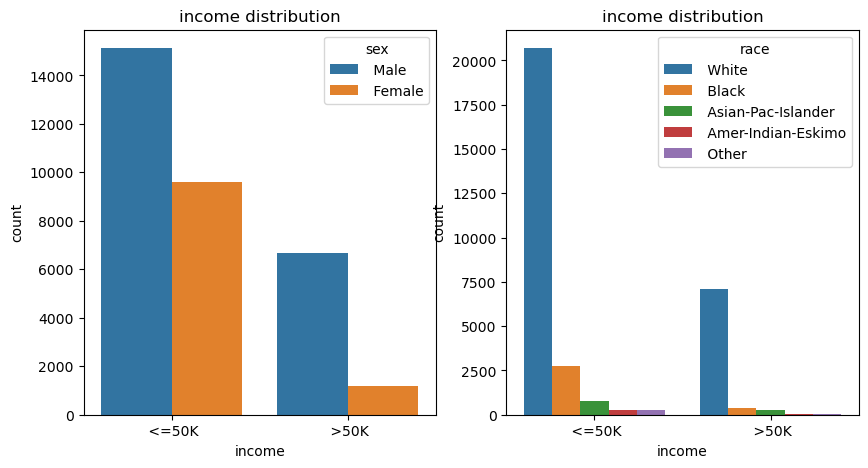

In [10]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x="income", hue="sex", data=data_frame)
plt.title("income distribution")

plt.subplot(1,2,2)
sns.countplot(x="income", hue="race", data=data_frame)
plt.title("income distribution")

plt.show()

In [11]:
print(data_frame["workclass"].value_counts(), data_frame["workclass"].unique())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']


In [12]:
data_frame["workclass"]= data_frame["workclass"].replace(" ?", np.nan)
print(data_frame["workclass"].value_counts(), data_frame["workclass"].unique())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 nan ' Self-emp-inc' ' Without-pay' ' Never-worked']


In [13]:
data_frame["occupation"]= data_frame["occupation"].replace(" ?", np.nan)
data_frame["native_country"]= data_frame["native_country"].replace(" ?", np.nan)

# Target and One Hat Encoding

In [14]:
X = data_frame.drop("income", axis =1)
y = data_frame["income"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=0)

In [16]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "O"] # we take the ones that are type objects
numerical = [col for col in X_train.columns if X_train[col].dtype != "O"] # we take the ones that are type numeric

In [17]:
print(X_train[categorical].isnull().sum())
print(X_test[categorical].isnull().sum())

workclass         1276
education            0
marital_status       0
occupation        1278
relationship         0
race                 0
sex                  0
native_country     414
dtype: int64
workclass         560
education           0
marital_status      0
occupation        565
relationship        0
race                0
sex                 0
native_country    169
dtype: int64


### We will fill the empty data with modes because they are categorical values.

In [18]:
for i in [X_train, X_test]:
    i["workclass"] = i["workclass"].fillna(X_train["workclass"].mode()[0])
    i["occupation"] = i["occupation"].fillna(X_train["occupation"].mode()[0])
    i["native_country"] = i["native_country"].fillna(X_train["native_country"].mode()[0])

In [19]:
print(X_train[categorical].isnull().sum())
print(X_test[categorical].isnull().sum())

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64
workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64


## Encoding

In [20]:
data_frame[categorical].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
dtype: int64

### For this, "One-hot-encoding" can be considered, but there are 41 values in "native_country". It would be too long for this. <br>-We say 1 for those who have >50k, we say 0 for those who don't,  we take the average, for example if the result is 0.3, we can say that 0.3 of the people in that country have >50k.<br>-we will do this for "native_country"

In [21]:
y_train_binary = y_train.apply(lambda x: 1 if x.strip() == ">50K" else 0)
print(y_train_binary)

32098    1
25206    0
23491    1
12367    0
7054     0
        ..
13123    1
19648    0
9845     0
10799    1
2732     0
Name: income, Length: 22792, dtype: int64


In [22]:
print(y_train_binary.groupby(X_train["native_country"]).mean())

native_country
Cambodia                      0.333333
Canada                        0.309524
China                         0.241379
Columbia                      0.021739
Cuba                          0.257143
Dominican-Republic            0.021277
Ecuador                       0.166667
El-Salvador                   0.101449
England                       0.295082
France                        0.300000
Germany                       0.284091
Greece                        0.263158
Guatemala                     0.041667
Haiti                         0.093750
Holand-Netherlands            0.000000
Honduras                      0.100000
Hong                          0.272727
Hungary                       0.111111
India                         0.391304
Iran                          0.366667
Ireland                       0.187500
Italy                         0.354167
Jamaica                       0.090909
Japan                         0.395349
Laos                          0.200000
Mexico    

In [23]:
target_means = y_train_binary.groupby(X_train["native_country"]).mean()

In [24]:
X_train["native_country_encoded"] = X_train["native_country"].map(target_means)
X_train["native_country_encoded"] = X_train["native_country_encoded"].fillna(y_train_binary.mean())

X_test["native_country_encoded"] = X_test["native_country"].map(target_means)
X_test["native_country_encoded"] = X_test["native_country_encoded"].fillna(y_train_binary.mean())

In [25]:
X_train = X_train.drop("native_country", axis=1)
X_test = X_test.drop("native_country", axis=1)
print(X_train.head())

       age   workclass  final_weight      education  education_num  \
32098   45     Private        170871        HS-grad              9   
25206   47   State-gov        108890        HS-grad              9   
23491   48     Private        187505   Some-college             10   
12367   29     Private        145592        HS-grad              9   
7054    23     Private        203003        7th-8th              4   

            marital_status     occupation    relationship    race      sex  \
32098   Married-civ-spouse   Craft-repair         Husband   White     Male   
25206             Divorced   Adm-clerical       Unmarried   White   Female   
23491   Married-civ-spouse          Sales         Husband   White     Male   
12367        Never-married   Craft-repair   Not-in-family   White     Male   
7054         Never-married   Craft-repair   Not-in-family   White     Male   

       capital_gain  capital_loss  hours_per_week  native_country_encoded  
32098          7298             0 

In [26]:
one_hot_categories = ['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex']

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [28]:
encoder = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_categories)
    ], remainder="passthrough"
)

#sparse_output --> so that the result does not come out as a matrix

In [29]:
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [30]:
print(encoder.get_feature_names_out())

['cat__workclass_ Federal-gov' 'cat__workclass_ Local-gov'
 'cat__workclass_ Never-worked' 'cat__workclass_ Private'
 'cat__workclass_ Self-emp-inc' 'cat__workclass_ Self-emp-not-inc'
 'cat__workclass_ State-gov' 'cat__workclass_ Without-pay'
 'cat__education_ 10th' 'cat__education_ 11th' 'cat__education_ 12th'
 'cat__education_ 1st-4th' 'cat__education_ 5th-6th'
 'cat__education_ 7th-8th' 'cat__education_ 9th'
 'cat__education_ Assoc-acdm' 'cat__education_ Assoc-voc'
 'cat__education_ Bachelors' 'cat__education_ Doctorate'
 'cat__education_ HS-grad' 'cat__education_ Masters'
 'cat__education_ Preschool' 'cat__education_ Prof-school'
 'cat__education_ Some-college' 'cat__marital_status_ Divorced'
 'cat__marital_status_ Married-AF-spouse'
 'cat__marital_status_ Married-civ-spouse'
 'cat__marital_status_ Married-spouse-absent'
 'cat__marital_status_ Never-married' 'cat__marital_status_ Separated'
 'cat__marital_status_ Widowed' 'cat__occupation_ Adm-clerical'
 'cat__occupation_ Armed-For

In [31]:
columnsss= encoder.get_feature_names_out()

In [32]:
X_train = pd.DataFrame(X_train_encoded, columns=columnsss, index=X_train.index)
X_test = pd.DataFrame(X_test_encoded, columns=columnsss, index=X_test.index)

## Scaling (no need, but let's do it, maybe another model can be used)

In [33]:
x_train_cols = X_train.columns

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=x_train_cols)
X_test = pd.DataFrame(X_test, columns=columnsss)

In [34]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__final_weight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.40,-0.058906,-0.333333,7298.0,0.0,4.0,0.000000
1,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,0.50,-0.578076,-0.333333,1831.0,0.0,-0.4,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.55,0.080425,0.000000,0.0,0.0,2.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.40,-0.270650,-0.333333,0.0,0.0,0.0,-0.204055
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.70,0.210240,-2.000000,0.0,0.0,-3.0,0.038369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22787,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.30,-1.210980,1.333333,0.0,0.0,0.0,0.000000
22788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.35,-0.665391,-1.333333,0.0,0.0,-1.0,0.000000
22789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.0,-0.70,-1.110582,0.000000,0.0,0.0,0.0,0.000000
22790,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.40,0.317951,2.000000,7688.0,0.0,1.0,0.000000


# Training

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rfc = RandomForestClassifier(n_estimators=10, random_state=15) # n_estimators= how many trees will there be

rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=15)

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8470672535571706
[[6886  521]
 [ 973 1389]]
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7407
        >50K       0.73      0.59      0.65      2362

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



#### n_estimators = 100;

In [38]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15) 

rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8537209540382844
[[6870  537]
 [ 892 1470]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [39]:
feature_scores = pd.Series(rfc.feature_importances_, index = X_train.columns).sort_values()
print(feature_scores,"\n")
print(feature_scores.head(10))

cat__workclass_ Never-worked        0.000007
cat__occupation_ Armed-Forces       0.000023
cat__education_ Preschool           0.000029
cat__workclass_ Without-pay         0.000075
cat__occupation_ Priv-house-serv    0.000097
                                      ...   
remainder__education_num            0.071245
remainder__hours_per_week           0.084592
remainder__capital_gain             0.095961
remainder__age                      0.148629
remainder__final_weight             0.159946
Length: 65, dtype: float64 

cat__workclass_ Never-worked              0.000007
cat__occupation_ Armed-Forces             0.000023
cat__education_ Preschool                 0.000029
cat__workclass_ Without-pay               0.000075
cat__occupation_ Priv-house-serv          0.000097
cat__education_ 1st-4th                   0.000250
cat__marital_status_ Married-AF-spouse    0.000285
cat__education_ 5th-6th                   0.000353
cat__race_ Other                          0.000837
cat__education_ 1

### bu son 10 sütun aslında bizim için çok önemli değil. Bunları atalım ve bir daha deneyelim. 

In [40]:
X_train = X_train.drop(["cat__education_ 12th", "cat__race_ Other", "cat__education_ 5th-6th",
                       "cat__marital_status_ Married-AF-spouse", "cat__education_ 1st-4th",
                        "cat__occupation_ Priv-house-serv", "cat__workclass_ Without-pay",
                        "cat__education_ Preschool", "cat__occupation_ Armed-Forces",
                        "cat__workclass_ Never-worked"
                       ], axis=1)

In [41]:
X_test = X_test.drop(["cat__education_ 12th", "cat__race_ Other", "cat__education_ 5th-6th",
                       "cat__marital_status_ Married-AF-spouse", "cat__education_ 1st-4th",
                        "cat__occupation_ Priv-house-serv", "cat__workclass_ Without-pay",
                        "cat__education_ Preschool", "cat__occupation_ Armed-Forces",
                        "cat__workclass_ Never-worked"
                       ], axis=1)

In [42]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15) 

rfc.fit(X_train, y_train)

y_pred_after_drop = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred_after_drop))
print(confusion_matrix(y_test, y_pred_after_drop))
print(classification_report(y_test, y_pred_after_drop))

0.853618589415498
[[6864  543]
 [ 887 1475]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



### There hasn't been much change, in fact it has decreased, but still cleanliness is important.

## HyperParameter Tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV

[Click to go to sklearn/randomForestClassifier documentation..](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [44]:
rf_params = {
    "n_estimators" : [100,150,200,250,300,500,1000],
    "max_depth" : [5, 8, 10, 15, None],
    "max_features" : ["sqrt", "log2", 5, 6, 7, 8],
    "min_samples_split" : [2, 8, 15, 20]
}

In [45]:
rscv = RandomizedSearchCV(estimator= RandomForestClassifier(), param_distributions=rf_params, cv=3, n_jobs=-1)

rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 10, 15, None],
                                        'max_features': ['sqrt', 'log2', 5, 6,
                                                         7, 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 150, 200, 250,
                                                         300, 500, 1000]})

In [48]:
y_pred_cv = rscv.predict(X_test)

print(accuracy_score(y_test, y_pred_cv))
print(confusion_matrix(y_test, y_pred_cv))
print(classification_report(y_test, y_pred_cv))

0.8630361347118436
[[6930  477]
 [ 861 1501]]
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7407
        >50K       0.76      0.64      0.69      2362

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [49]:
rscv.best_params_

{'n_estimators': 200,
 'min_samples_split': 15,
 'max_features': 7,
 'max_depth': None}